In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numpy.linalg as LA
import scipy.constants as const
from scipy.spatial.transform import Rotation

import matplotlib.pyplot as plt
%matplotlib ipympl


import sys
sys.path.append('E:/google-drive/py_projects/satellites/src')
# import satellites as sat
import stateest as se


Estimates: ['-219.52', '-217.18', '-212.69', '-205.04', '-190.75', '-173.21', '-151.29', '-125.77', '-91.92', '-51.32', '-8.73', '49.23', '106.54', '173.94', '225.11', '251.03', '317.84', '371.69', '426.35', '445.29', '488.31', '519.88', '555.45', '587.23', '636.36', '648.02', '672.69', '728.47', '756.24', '765.38', '775.03', '794.38', '791.10', '806.88', '815.44', '865.19', '877.39', '894.59', '915.25', '940.33', '957.09', '989.09', '1004.54', '1012.60', '1040.95', '1060.57', '1092.86', '1112.81', '1155.25', '1183.48', '1205.27', '1221.32', '1232.89']


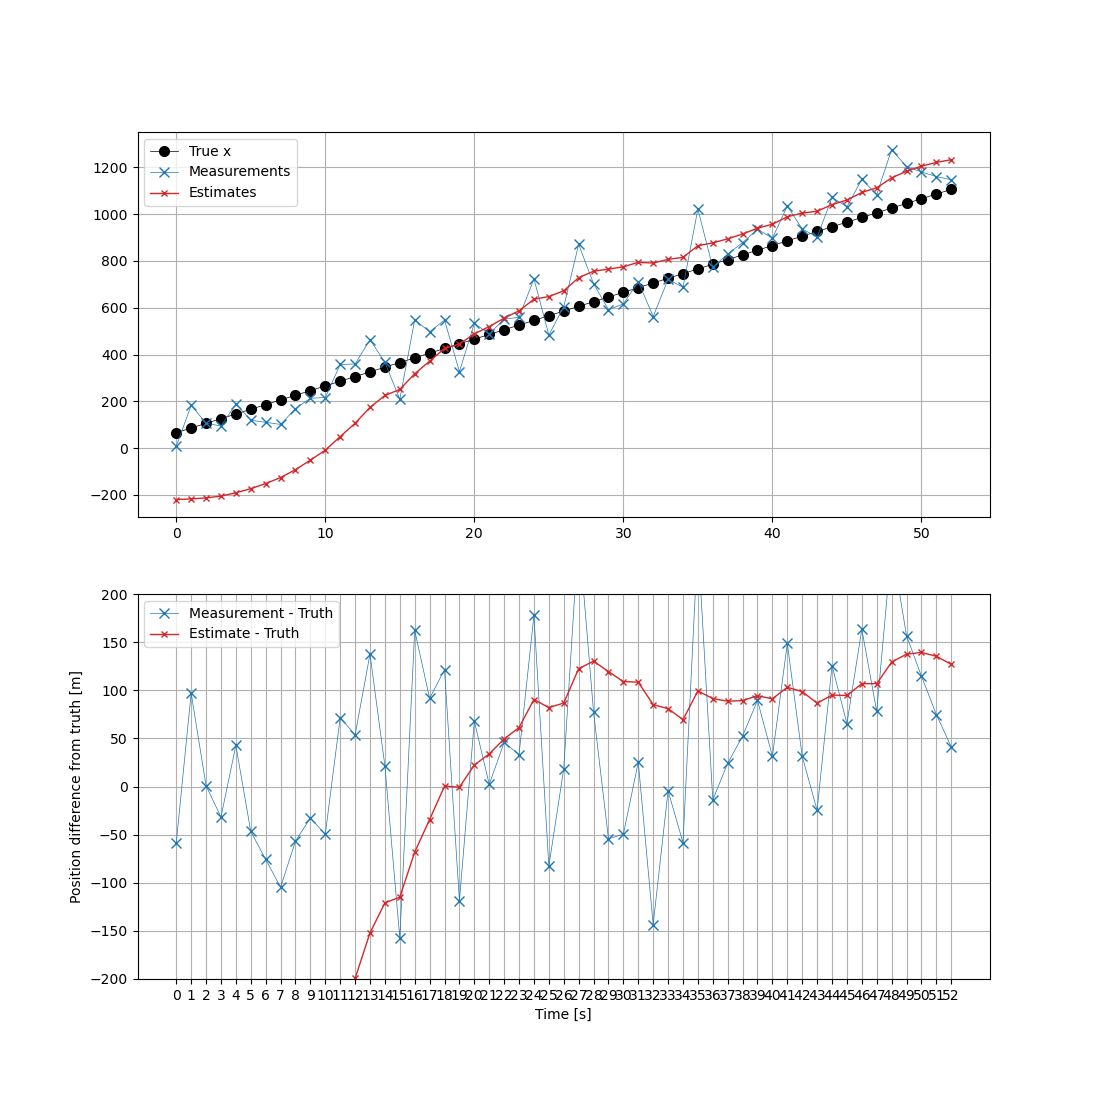

In [7]:

rng = np.random.default_rng(seed=2318)
# --- Example: tracking 1D position with constant velocity ---
dt = 1.0

F = np.array([[1, dt],
              [0,  1]])       # state: [position, velocity]

H = np.array([[1, 0]])       # we only observe position

Q = np.array([[1, 0],
              [0, 1]]) * 0.1 # process noise

R = np.array([[1000.0]])        # measurement noise

x0 = np.reshape([-220,0], [-1,1])    # initial state
P0 = np.array([
    [1, 0],
    [0, 1],
])         # high initial uncertainty

B = np.eye(2)
u = np.zeros_like(x0)

kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

# Simulate some noisy measurements
timevec = np.arange(53) * dt
true_positions = 20.0 * timevec + 66


measurements = 1.1*true_positions - 11 + rng.normal(0, 100.3, true_positions.shape) 


estimates = []
for z in measurements:
    # kf.model_predition_step()
    # x_est, _ = kf.measurement_update_step(np.array([[z]]), {'stable':True})
    x_est, _ = kf.perform_epoch(u=None, z=np.array([[z]]), postcovkwargs={'stable':True})
    estimates.append(x_est[0, 0])

print("Estimates:", [f"{e:.2f}" for e in estimates])


fig, axs = plt.subplots(2,1, figsize=[11,11])
axs[0].plot(timevec, true_positions, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[0].plot(timevec, measurements, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[0].plot(timevec, estimates, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[0].legend()
axs[1].plot(timevec, measurements - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
axs[1].plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
axs[1].legend()

axkwargs = {
    'xticks': timevec,
    'ylim': [-200, 200],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
axs[1].set(**axkwargs)
for ax in axs:
    ax.grid(True)
plt.show()